# Лабораторна робота №2 ІАД
**Тема:** NumPy, pandas і Matplotlib для підготовки, аналізу та візуалізації даних  
**Мета:** Ознайомитися з основами роботи з бібліотеками NumPy, Pandas та Matplotlib для аналізу даних.  
**Студент:** Чернега Катерина, Група: МІТ-31  
**Варіант:** 4 (Відстань робота)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Параметри Варіанта 4
seed = 4
a = 0.8
b = 1.5
sigma = 0.7

In [3]:
#Генерація даних за параметрами варіанта
rng = np.random.default_rng(seed)
x = np.linspace(0, 20, 100)
y_true = a * x + b
noise = rng.normal(loc=0, scale=sigma, size=x.size)
y_observed = y_true + noise

#Об'єднання масивів у єдину матрицю (по стовпцях)
matrix = np.column_stack((x, y_true, noise, y_observed))

#Виведення структури масиву
print("--- Завдання 4: Структура масиву ---")
print("Shape (форма):", matrix.shape)
print("Ndim (кількість вимірів):", matrix.ndim)
print("Size (кількість елементів):", matrix.size)
print("Dtype (тип даних):", matrix.dtype)

--- Завдання 4: Структура масиву ---
Shape (форма): (100, 4)
Ndim (кількість вимірів): 2
Size (кількість елементів): 400
Dtype (тип даних): float64


**Пояснення структури масиву:**
* `shape` показує форму масиву. Результат (100, 4) означає, що матриця має 100 рядків (наші згенеровані вимірювання) та 4 стовпці (x, y_true, noise, y_observed).
* `dtype` показує тип даних елементів. Результат `float64` означає, що всі числа в матриці є дійсними числами з рухомою комою подвійної точності.

In [4]:
#Завдання 5: Індексація, зрізи, фільтрація, копія, видалення
print("--- Завдання 5: Робота з масивами ---")
print("1. Читання через індекс (перший елемент y_observed):", y_observed[0])
print("2. Зріз (перші 5 елементів x):", x[:5])

#Булева фільтрація 
filtered_y = y_observed[y_observed > 5]
print("3. Кількість елементів y_observed, які більші за 5:", filtered_y.size)

#Оновлення копії фрагмента (щоб не змінити оригінал через view)
y_copy = y_observed.copy()
y_copy[:3] = 0
print("4. Перші 3 елементи зміненої копії:", y_copy[:3])
print("   Перші 3 елементи оригіналу (залишилися без змін):", y_observed[:3])

#Видалення елемента (видаляємо перший елемент з копії)
y_deleted = np.delete(y_copy, 0)
print("5. Розмір копії після видалення одного елемента:", y_deleted.size)

#Завдання 6: Статистика та агрегація
print("\n--- Завдання 6: Статистика ---")
print(f"Мінімум y_observed: {np.min(y_observed):.2f}")
print(f"Максимум y_observed: {np.max(y_observed):.2f}")
print(f"Середнє y_observed: {np.mean(y_observed):.2f}")
print(f"Стандартне відхилення y_observed: {np.std(y_observed):.2f}")

#Агрегація з axis=0 для всієї матриці
means_axis0 = np.mean(matrix, axis=0)
print("\nСереднє по кожному стовпцю матриці (axis=0):")
print("x, y_true, noise, y_observed =", means_axis0)

--- Завдання 5: Робота з масивами ---
1. Читання через індекс (перший елемент y_observed): 1.0437461931718173
2. Зріз (перші 5 елементів x): [0.         0.2020202  0.4040404  0.60606061 0.80808081]
3. Кількість елементів y_observed, які більші за 5: 78
4. Перші 3 елементи зміненої копії: [0. 0. 0.]
   Перші 3 елементи оригіналу (залишилися без змін): [1.04374619 1.53931406 2.98783912]
5. Розмір копії після видалення одного елемента: 99

--- Завдання 6: Статистика ---
Мінімум y_observed: 1.00
Максимум y_observed: 17.97
Середнє y_observed: 9.46
Стандартне відхилення y_observed: 4.73

Середнє по кожному стовпцю матриці (axis=0):
x, y_true, noise, y_observed = [10.          9.5        -0.04431187  9.45568813]


**Висновок до блоку NumPy:**
Було згенеровано масив даних для предметної області "Відстань робота". 
Продемонстровано створення копії масиву (`copy()`), що дозволяє безпечно змінювати дані без ризику випадково змінити оригінал (через `view`). 
Використання параметра `axis=0` під час агрегації матриці дозволило обчислити середнє значення не для всіх елементів разом, а окремо вздовж кожного стовпця (тобто окремо для `x`, `y_true`, `noise` та `y_observed`).

In [7]:

#Завдання 1: Створення DataFrame
print("--- Завдання 1: Створення DataFrame ---")
df = pd.DataFrame({
    "x": x,
    "y_true": y_true,
    "noise": noise,
    "y_observed": y_observed
})

#Додаємо стовпець group (поділ x на 3 рівні інтервали)
df['group'] = pd.cut(df['x'], bins=3, labels=['low', 'medium', 'high'])
print("Стовпець 'group' успішно додано.")

#Завдання 2: Первинний аналіз
print("\n--- Завдання 2: Первинний аналіз ---")
print("\nПерші 5 рядків (head):")
display(df.head()) # display() малює гарну табличку в Jupyter

print("\nФорма таблиці (shape):", df.shape)
print("\nТипи даних (dtypes):\n", df.dtypes)

print("\nЗагальна інформація (info):")
df.info()

print("\nОписова статистика (describe):")
display(df.describe())

--- Завдання 1: Створення DataFrame ---
Стовпець 'group' успішно додано.

--- Завдання 2: Первинний аналіз ---

Перші 5 рядків (head):


,x,y_true,noise,y_observed,group
0,0.000000,1.500000,-0.456254,1.043746,low
1,0.202020,1.661616,-0.122302,1.539314,low
2,0.404040,1.823232,1.164607,2.987839,low
3,0.606061,1.984848,0.461403,2.446252,low
4,0.808081,2.146465,-1.148978,0.997487,low



Форма таблиці (shape): (100, 5)

Типи даних (dtypes):
 x              float64
y_true         float64
noise          float64
y_observed     float64
group         category
dtype: object

Загальна інформація (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   x           100 non-null    float64 
 1   y_true      100 non-null    float64 
 2   noise       100 non-null    float64 
 3   y_observed  100 non-null    float64 
 4   group       100 non-null    category
dtypes: category(1), float64(4)
memory usage: 3.5 KB

Описова статистика (describe):


,x,y_true,noise,y_observed
count,100.000000,100.000000,100.000000,100.000000
mean,10.000000,9.500000,-0.044312,9.455688
std,5.860907,4.688726,0.712053,4.749471
min,0.000000,1.500000,-1.482642,0.997487
25%,5.000000,5.500000,-0.548306,5.301065
50%,10.000000,9.500000,-0.084656,9.307795
75%,15.000000,13.500000,0.477809,13.208839
max,20.000000,17.500000,1.698354,17.972972


In [8]:
#Завдання 3: Додавання пропусків та дублікатів ---
print("--- Завдання 3 та 4: Робота з пропущеними даними та дублікатами ---")

#Працюємо з копією, щоб не зіпсувати оригінальні дані
df_dirty = df.copy()

#Штучно додаємо 3 пропуски (NaN) у стовпець y_observed через .loc
df_dirty.loc[15, 'y_observed'] = np.nan
df_dirty.loc[50, 'y_observed'] = np.nan
df_dirty.loc[85, 'y_observed'] = np.nan

#Штучно додаємо 1 дубльований рядок (копіюємо перший рядок у кінець таблиці)
df_dirty = pd.concat([df_dirty, df_dirty.iloc[[0]]], ignore_index=True)

#Завдання 4: Підрахунок та очищення ---
print("Форма таблиці ДО очищення:", df_dirty.shape)
print("Кількість дублікатів ДО очищення:", df_dirty.duplicated().sum())
print("Пропусків у y_observed ДО очищення:", df_dirty['y_observed'].isna().sum())

#1.Видаляємо дублікати
df_clean = df_dirty.drop_duplicates()

#2.Заповнюємо пропуски медіаною
median_val = df_clean['y_observed'].median()
#Використовуємо рекомендований pandas спосіб для оновлення стовпця
df_clean.loc[:, 'y_observed'] = df_clean['y_observed'].fillna(median_val)

print("\nФорма таблиці ПІСЛЯ очищення:", df_clean.shape)
print("Кількість дублікатів ПІСЛЯ очищення:", df_clean.duplicated().sum())
print("Пропусків у y_observed ПІСЛЯ очищення:", df_clean['y_observed'].isna().sum())

--- Завдання 3 та 4: Робота з пропущеними даними та дублікатами ---
Форма таблиці ДО очищення: (101, 5)
Кількість дублікатів ДО очищення: 1
Пропусків у y_observed ДО очищення: 3

Форма таблиці ПІСЛЯ очищення: (100, 5)
Кількість дублікатів ПІСЛЯ очищення: 0
Пропусків у y_observed ПІСЛЯ очищення: 0


**Висновок до очищення даних:**
Пропуски у вимірюваннях (наприклад, збої датчика відстані) не можна просто видаляти, оскільки ми втратимо відповідні значення `x` (часу). Заповнення медіаною було обрано тому, що ця метрика стійка до аномальних викидів (шуму) і дозволяє зберегти загальний розподіл даних краще, ніж заповнення середнім арифметичним. Видалення дублікатів повернуло таблиці початковий розмір (100 рядків).

In [9]:
#Завдання 5: loc, iloc, фільтрація та сортування ---
print("--- Завдання 5: loc, iloc, фільтрація, сортування ---")

#1.Демонстрація loc (за мітками/умовами) 
# Вибираємо рядки, де x > 15, і показуємо лише стовпці 'x' та 'y_observed'
print("\n1. Фільтрація через loc (x > 15):")
display(df_clean.loc[df_clean['x'] > 15, ['x', 'y_observed']].head())

#2.Демонстрація iloc (за числовими індексами) 
# Вибираємо перші 3 рядки і перші 3 стовпці
print("\n2. Вибірка через iloc (перші 3 рядки, перші 3 стовпці):")
display(df_clean.iloc[0:3, 0:3])

#3.Булева фільтрація 
# Шукаємо рядки, де шум був більшим за 1.0
print("\n3. Булева фільтрація (шум > 1.0):")
high_noise = df_clean[df_clean['noise'] > 1.0]
display(high_noise.head())

#4.Сортування 
# Сортуємо таблицю за відстанню (y_observed) за спаданням
print("\n4. Сортування за y_observed (за спаданням, перші 5 рядків):")
sorted_df = df_clean.sort_values(by='y_observed', ascending=False)
display(sorted_df.head())

#Завдання 6: Групування ---
print("\n--- Завдання 6: Групування за стовпцем 'group' ---")
#Групуємо за трьома інтервалами (low, medium, high) і рахуємо статистику
grouped_df = df_clean.groupby('group', observed=False)['y_observed'].agg(['mean', 'std', 'size', 'count'])

display(grouped_df)

--- Завдання 5: loc, iloc, фільтрація, сортування ---

1. Фільтрація через loc (x > 15):


,x,y_observed
75,15.151515,14.364665
76,15.353535,13.202186
77,15.555556,13.770298
78,15.757576,12.924090
79,15.959596,12.931419



2. Вибірка через iloc (перші 3 рядки, перші 3 стовпці):


,x,y_true,noise
0,0.00000,1.500000,-0.456254
1,0.20202,1.661616,-0.122302
2,0.40404,1.823232,1.164607



3. Булева фільтрація (шум > 1.0):


,x,y_true,noise,y_observed,group
2,0.404040,1.823232,1.164607,2.987839,low
11,2.222222,3.277778,1.102938,4.380716,low
15,3.030303,3.924242,1.576910,9.236889,low
24,4.848485,5.378788,1.037800,6.416588,low
48,9.696970,9.257576,1.440680,10.698256,medium



4. Сортування за y_observed (за спаданням, перші 5 рядків):


,x,y_true,noise,y_observed,group
97,19.595960,17.176768,0.796205,17.972972,high
98,19.797980,17.338384,0.362679,17.701062,high
94,18.989899,16.691919,0.875488,17.567407,high
99,20.000000,17.500000,-0.026133,17.473867,high
96,19.393939,17.015152,0.115667,17.130818,high



--- Завдання 6: Групування за стовпцем 'group' ---


,mean,std,size,count
group,,,,
low,4.175800,1.911303,34,34
medium,9.614591,1.690509,33,33
high,14.642340,1.993654,33,33


**Висновок до фільтрації та групування:**
За допомогою `loc` та `iloc` дуже зручно робити вибірки даних за логічними умовами або числовими індексами. Після групування даних за категорією `group` ми отримали агреговану статистику для трьох інтервалів часу.

**Відмінність `size()` від `count()`:** 
Метод `size()` повертає загальну кількість рядків у кожній групі, незалежно від того, чи є в них пропуски (`NaN`). Натомість `count()` підраховує **лише** ті рядки, де значення не є порожнім. Оскільки на попередньому етапі ми заповнили всі пропуски медіаною, у нашій агрегованій таблиці результати `size` та `count` зараз повністю однакові.

--- Обчислення MAE та MSE ---
Середня абсолютна похибка (MAE): 0.6656 м
Середня квадратична похибка (MSE): 1.1171 м²


C:\Users\Катерина\AppData\Local\Temp\ipykernel_2664\2223631235.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['absolute_error'] = np.abs(df_clean['y_observed'] - df_clean['y_true'])
C:\Users\Катерина\AppData\Local\Temp\ipykernel_2664\2223631235.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['squared_error'] = (df_clean['y_observed'] - df_clean['y_true']) ** 2


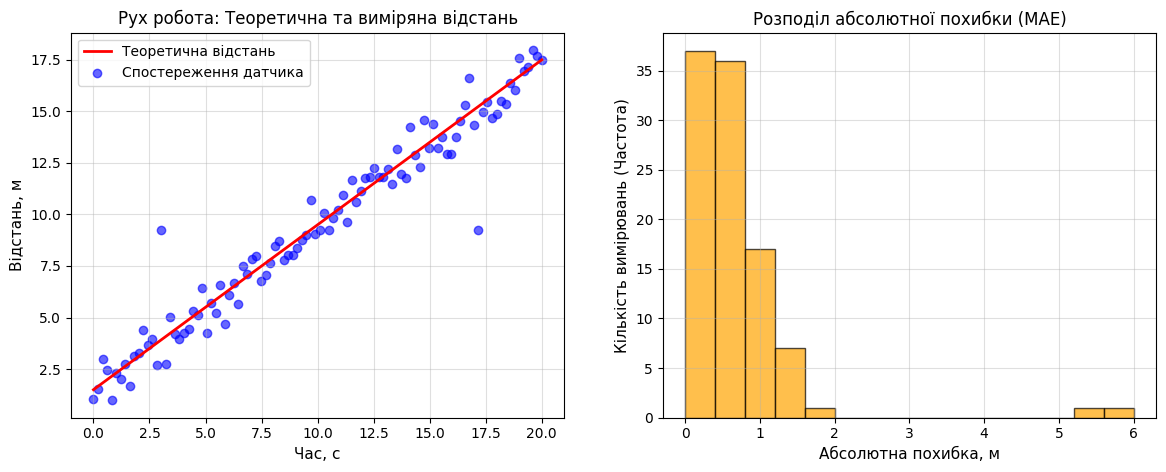


Файли успішно збережено: Lab2_results.csv, Lab2_results.parquet, Lab2_summary.csv, Lab2_plot.png


In [10]:
#Метрики похибок (MAE та MSE)
print("--- Обчислення MAE та MSE ---")

#Додаємо стовпці з похибками до нашої таблиці
df_clean['absolute_error'] = np.abs(df_clean['y_observed'] - df_clean['y_true'])
df_clean['squared_error'] = (df_clean['y_observed'] - df_clean['y_true']) ** 2

#Обчислюємо загальні MAE та MSE
mae = np.mean(df_clean['absolute_error'])
mse = np.mean(df_clean['squared_error'])

print(f"Середня абсолютна похибка (MAE): {mae:.4f} м")
print(f"Середня квадратична похибка (MSE): {mse:.4f} м²")

#Matplotlib: Візуалізація результатів ---
#Створюємо полотно з двома графіками поруч (1 рядок, 2 колонки)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

#1.Лівий графік: Лінія y_true та точки y_observed
axes[0].plot(df_clean['x'], df_clean['y_true'], color='red', label='Теоретична відстань', linewidth=2)
axes[0].scatter(df_clean['x'], df_clean['y_observed'], color='blue', alpha=0.6, label='Спостереження датчика')
axes[0].set_title("Рух робота: Теоретична та виміряна відстань", fontsize=12)
axes[0].set_xlabel("Час, с", fontsize=11)
axes[0].set_ylabel("Відстань, м", fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.4)

#2.Правий графік: Гістограма абсолютної похибки
axes[1].hist(df_clean['absolute_error'], bins=15, color='orange', edgecolor='black', alpha=0.7)
axes[1].set_title("Розподіл абсолютної похибки (MAE)", fontsize=12)
axes[1].set_xlabel("Абсолютна похибка, м", fontsize=11)
axes[1].set_ylabel("Кількість вимірювань (Частота)", fontsize=11)
axes[1].grid(True, alpha=0.4)

#Зберігаємо рисунок у високій якості
plt.savefig("Lab2_plot.png", dpi=300, bbox_inches='tight')
plt.show()

#Збереження даних у файли 
df_clean.to_csv("Lab2_results.csv", index=False)
df_clean.to_parquet("Lab2_results.parquet", index=False)
grouped_df.to_csv("Lab2_summary.csv")

print("\nФайли успішно збережено: Lab2_results.csv, Lab2_results.parquet, Lab2_summary.csv, Lab2_plot.png")

## Підсумковий висновок
У цій лабораторній роботі було згенеровано та проаналізовано дані для предметної області "Відстань робота". 
За допомогою бібліотеки NumPy обчислено базові статистики. За допомогою pandas таблицю очищено від пропусків (заповнення медіаною) та дублікатів, а також згруповано за часовими інтервалами. 

Було розраховано дві метрики похибок, обидві є невід'ємними числами:
* **MAE (Середня абсолютна похибка):** показує, що в середньому вимірювання датчика відхиляються від реальної відстані робота на відповідну кількість метрів.
* **MSE (Середня квадратична похибка):** виражається у квадратних метрах і сильніше штрафує великі відхилення (викиди шуму).

Візуалізація за допомогою Matplotlib підтвердила лінійну залежність відстані від часу та дозволила наочно оцінити розподіл похибки вимірювань.